In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Read the dataset
data = pd.read_csv('dataset/churn.csv')
data = data.drop(columns=['customer_id','country','gender'])

#pisahkan data fitur dan target
X = data.drop(columns=['churn'])
y = data['churn']

X.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [3]:
# normalisasi data supaya lebih gampang diproses
X = StandardScaler().fit_transform(X)

# bagi data menjadi train dan test split 60:20:20

# train nya 60% terus temp nya 40% dari awalnya 100%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
# val dan test nya masing-masing 20% dari awalnya 100% (jadi 50% dari temp)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Single Layer Perceptron

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],)), # tambahin klo mw multilayer
])
# unit 1 --> 0 / 1
# sigmoid --> probability --> threshold (0.2)
# input_shape --> X_train.shape[1] --> jumlah fitur


/opt/homebrew/Caskroom/miniforge/base/envs/ai-core/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-07 22:20:20.417592: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-09-07 22:20:20.417853: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-07 22:20:20.417859: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-09-07 22:20:20.418136: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-07 22:20:20.418550: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_

In [5]:
# build model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
# train data
# history --> simpan loss dan hasil accuracy nya
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/100


2026-09-07 22:23:36.630680: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4708 - loss: 0.8497 - val_accuracy: 0.5235 - val_loss: 0.7534
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5428 - loss: 0.7247 - val_accuracy: 0.6125 - val_loss: 0.6576
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6415 - loss: 0.6357 - val_accuracy: 0.7150 - val_loss: 0.5906
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7323 - loss: 0.5750 - val_accuracy: 0.7575 - val_loss: 0.5457
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7702 - loss: 0.5341 - val_accuracy: 0.7710 - val_loss: 0.5153
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7782 - loss: 0.5064 - val_accuracy: 0.7765 - val_loss: 0.4947
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7857 - loss: 0.4873 - val_accuracy: 0.7810 - val_loss: 0.4802
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7905 - loss: 0.4741 - val_accuracy: 0.78

In [7]:
# evaluasi dengan hitung loss dan accuracy di data test
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8120 - loss: 0.4358
Test Loss: 0.4358135163784027
Test Accuracy: 0.8119999766349792


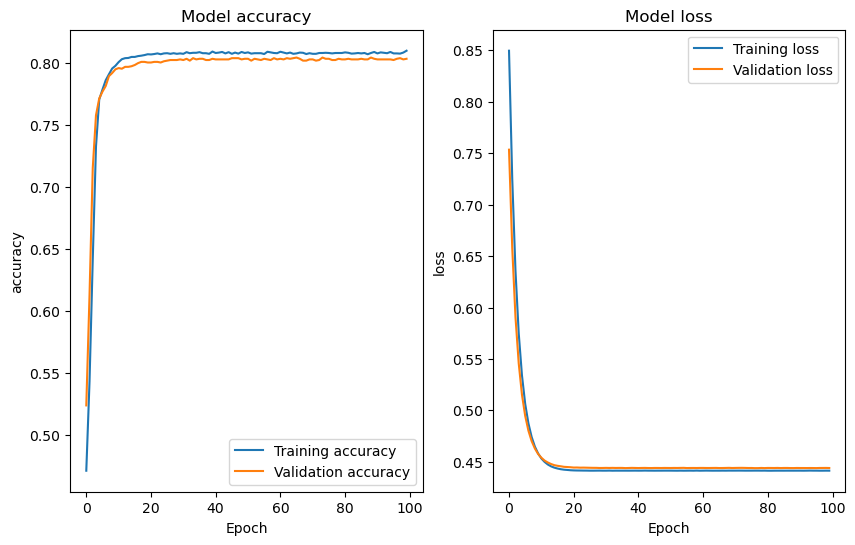

In [8]:
# plotting

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

# Multi Layer Perceptron

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2), # kalau mau pake dropout, bisa ditambahin di sini
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/opt/homebrew/Caskroom/miniforge/base/envs/ai-core/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# build model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
# train data
# history --> simpan loss dan hasil accuracy nya
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6985 - loss: 0.6054 - val_accuracy: 0.7815 - val_loss: 0.4929
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7792 - loss: 0.4942 - val_accuracy: 0.7815 - val_loss: 0.4582
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7933 - loss: 0.4718 - val_accuracy: 0.7880 - val_loss: 0.4502
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7963 - loss: 0.4662 - val_accuracy: 0.7905 - val_loss: 0.4474
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7942 - loss: 0.4657 - val_accuracy: 0.7910 - val_loss: 0.4470
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7968 - loss: 0.4607 - val_accuracy: 0.7965 - val_loss: 0.4493
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8018 - loss: 0.4550 - val_accuracy: 0.7955 - val_loss: 0.4487
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7972 - loss: 0.4575 - 

In [12]:
# evaluasi dengan hitung loss dan accuracy di data test
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8190 - loss: 0.6691
Test Loss: 0.669147253036499
Test Accuracy: 0.8190000057220459


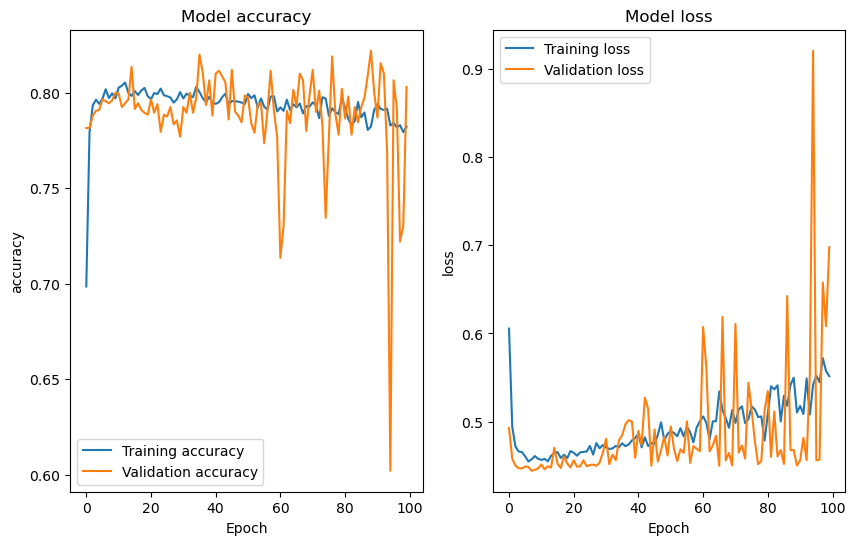

In [13]:
# plotting

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

# additional

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8190 - loss: 0.6691
Single Layer Test Accuracy: 0.8190000057220459
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8190 - loss: 0.6691
Multi Layer Test Accuracy: 0.8190000057220459


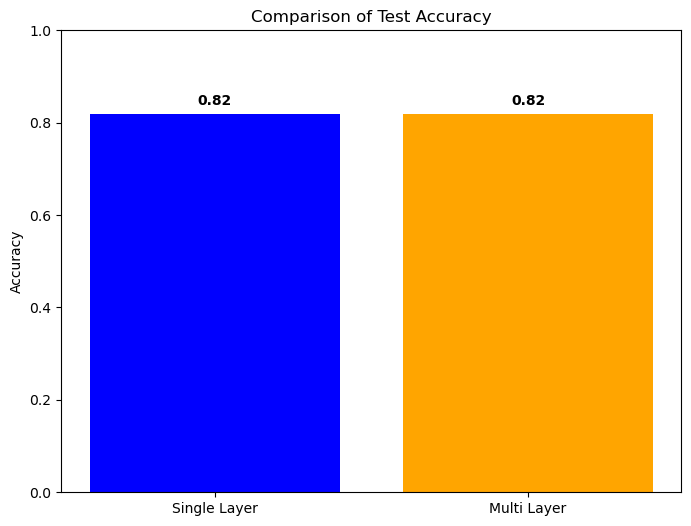

In [14]:
# Comparison Single Layer vs Multi Layer
accuracy_single_layer = model.evaluate(X_test, y_test)[1]
print(f'Single Layer Test Accuracy: {accuracy_single_layer}')
accuracy_multi_layer = model.evaluate(X_test, y_test)[1]
print(f'Multi Layer Test Accuracy: {accuracy_multi_layer}')

plt.figure(figsize=(8, 6))
plt.bar(['Single Layer', 'Multi Layer'], [accuracy_single_layer, accuracy_multi_layer], color=['blue', 'orange'])
plt.title('Comparison of Test Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate([accuracy_single_layer, accuracy_multi_layer]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show() 